# Skin Disorder Prediction using Machine Learning

## Problem Statement
Erythemato-squamous diseases share similar clinical and histopathological features, making accurate diagnosis challenging. These diseases include psoriasis, seborrheic dermatitis, lichen planus, pityriasis rosea, chronic dermatitis, and pityriasis rubra pilaris.

The objective of this project is to build a machine learning model that can predict the type of skin disease based on clinical and histopathological features.

## Project Objectives
- Perform exploratory data analysis (EDA)
- Preprocess and clean the dataset
- Train multiple machine learning models
- Compare model performance
- Select the best model for prediction
- Provide insights that may help doctors in early diagnosis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset
The dataset contains clinical and histopathological features used to diagnose different types of skin diseases.

In [2]:
df = pd.read_csv("dermatology.csv")
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [3]:
df.shape

(366, 35)

In [4]:
df.info

<bound method DataFrame.info of      erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0           2        2                 0        3                   0   
1           3        3                 3        2                   1   
2           2        1                 2        3                   1   
3           2        2                 2        0                   0   
4           2        3                 2        2                   2   
..        ...      ...               ...      ...                 ...   
361         2        1                 1        0                   1   
362         3        2                 1        0                   1   
363         3        2                 2        2                   3   
364         2        1                 3        1                   2   
365         3        2                 2        0                   0   

     polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  

In [5]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [6]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [7]:
df['Age'] = df['Age'].replace('?', np.nan)

In [8]:
df['Age'] = pd.to_numeric(df['Age'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                        

## Missing Value Analysis

The dataset was checked for missing values across all features.  
Initially, the **Age** column contained missing values represented as "?". These values were replaced with NaN and imputed using the **median age** of the dataset.

After preprocessing, the dataset contains **no missing values**, ensuring that machine learning models can be trained without data quality issues.

## Exploratory Data Analysis (EDA)

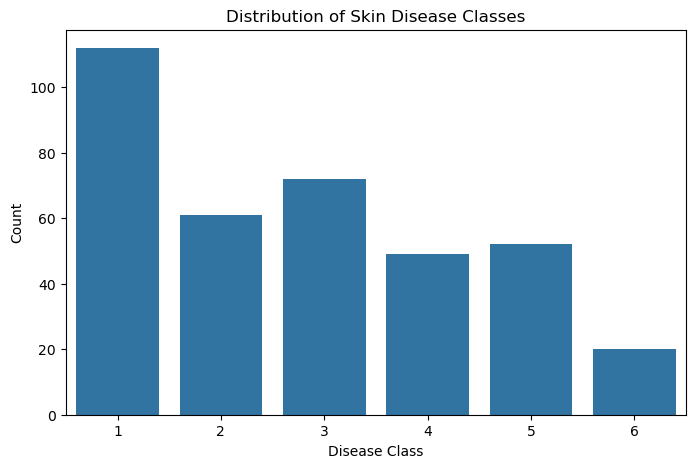

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['class'])

plt.title("Distribution of Skin Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Count")

plt.show()

### Insight

The class distribution plot shows how samples are distributed across the different skin disease categories. The dataset appears relatively balanced across most classes, meaning no single disease category dominates the dataset. A balanced class distribution is beneficial because it reduces the risk of the model becoming biased toward a particular class during training.

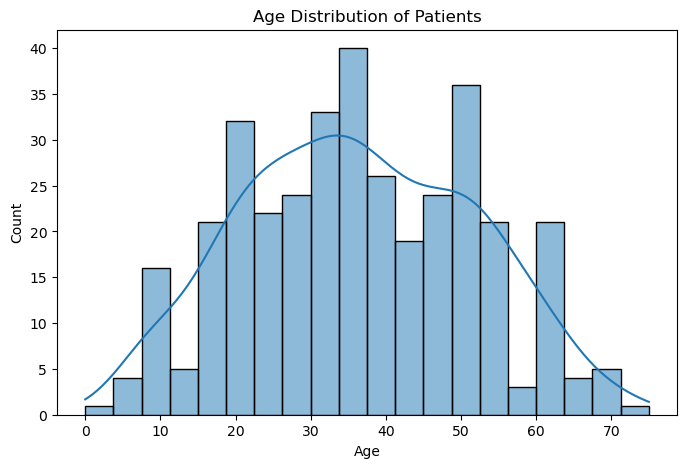

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution of Patients")

plt.show()

### Insight

The age distribution histogram shows the spread of patient ages in the dataset. Most observations appear to fall within a specific age range, indicating that the dataset primarily represents patients from those age groups. Understanding the age distribution helps identify whether certain age groups are more frequently represented in the dataset.

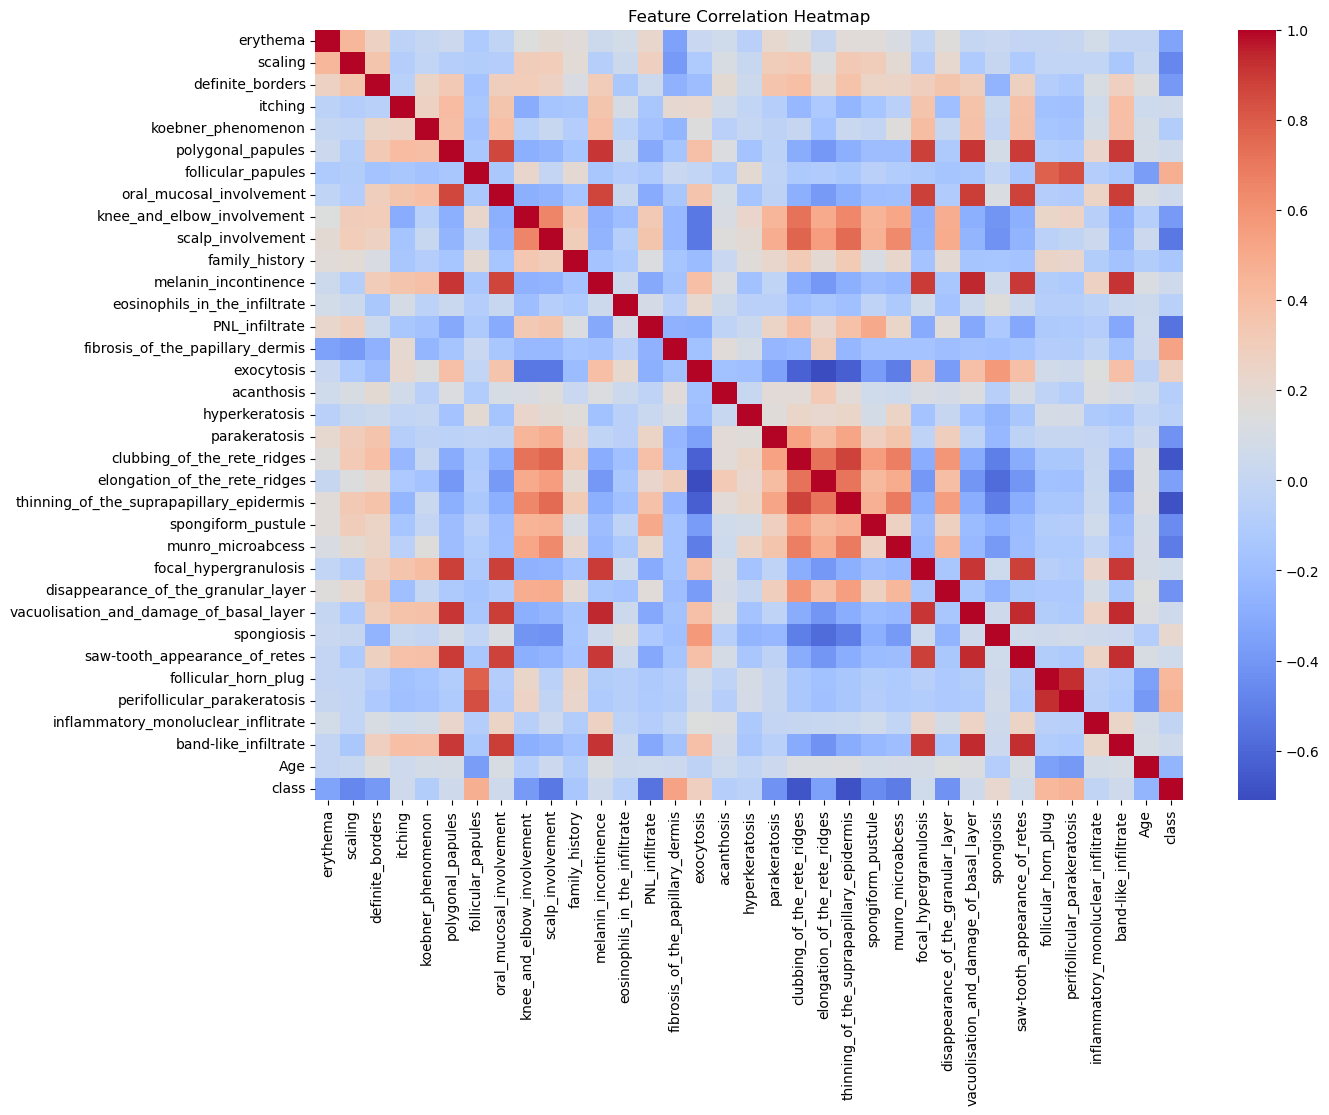

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

### Insight

The correlation heatmap visualizes relationships between different clinical and histopathological features in the dataset. Strong positive or negative correlations indicate that certain attributes tend to occur together. This analysis helps identify patterns among medical features and provides insight into which attributes may contribute most strongly to disease classification.

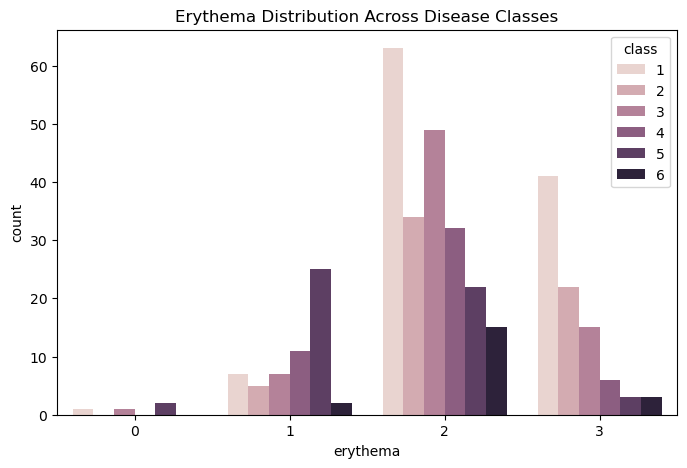

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['erythema'], hue=df['class'])

plt.title("Erythema Distribution Across Disease Classes")

plt.show()

### Insight

The visualization highlights the distribution of erythema levels across the different disease classes. Some classes exhibit higher concentrations of erythema values, indicating that redness and inflammation are key characteristics of those skin conditions.

The variation of erythema levels between classes suggests that this feature provides useful discriminatory information for classification models. As a result, erythema is likely to be an important predictor in identifying and differentiating between various dermatological diseases.

### Observations

- The dataset contains multiple disease classes with varying frequencies.
- Age distribution shows that patients across different age groups are affected.
- Correlation heatmap indicates relationships between several clinical and histopathological features.
- Features such as erythema show variation across disease classes, suggesting their importance in diagnosis.

## Feature and Target Separation

For machine learning models, the dataset is separated into:

- **Features (X)** → All input variables
- **Target (y)** → The disease class we want to predict

In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
X = df.drop("class", axis=1)
y = df["class"]

## Train-Test Split

The dataset is divided into training and testing sets.  
80% of the data is used for training the models and 20% for testing their performance.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

Standardization is applied to scale the feature values so that all variables contribute equally to model training.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train  = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

## Model 1: Logistic Regression

Logistic Regression is a widely used classification algorithm that models the probability of a categorical outcome.

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.9864864864864865


## Model 2: Decision Tree Classifier

Decision Tree is a supervised learning algorithm that splits the dataset into branches based on feature values to make predictions. It is easy to interpret and works well for classification problems.

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.9864864864864865


## Model 3: Random Forest Classifier

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions. It usually improves accuracy and reduces overfitting compared to a single decision tree.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.9864864864864865


## Model Comparison Report

The performance of multiple machine learning models is compared based on their accuracy scores in order to identify the most suitable model for predicting skin diseases.

In [21]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracies = [acc_lr, acc_dt, acc_rf]

comparison = pd.DataFrame({
    "Model" : models,
    "Accuracy" : accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.986486
1,Decision Tree,0.986486
2,Random Forest,0.986486


## Detailed Model Evaluation

After comparing the accuracy of different models, we further analyze their performance using 
classification reports and confusion matrices. These metrics provide deeper insights into 
precision, recall, and F1-score for each class, allowing a more comprehensive evaluation of 
model performance.

### Model Performance Analysis

All three models (Logistic Regression, Decision Tree, and Random Forest) achieved very high and nearly identical accuracy scores on the test dataset.

This occurs because the dermatology dataset contains highly informative clinical and histopathological features that strongly correlate with the disease classes. As a result, even relatively simple models are able to learn clear decision boundaries between classes.

Additionally, the dataset size is relatively small, which can cause different algorithms to produce similar predictive performance when evaluated using accuracy alone.

Although the accuracy scores appear identical, Random Forest is generally considered the most robust model because it combines multiple decision trees and reduces the risk of overfitting.

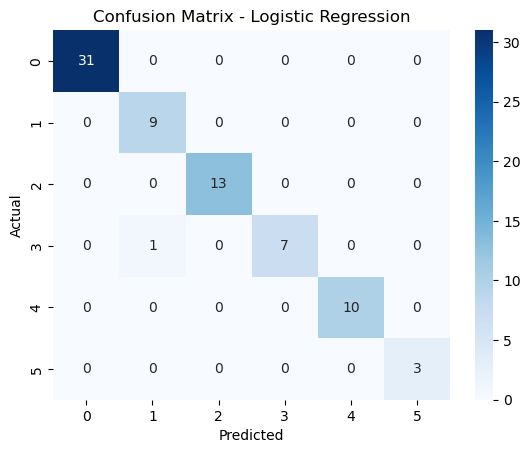

In [22]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
print("Logistic Regression Report")

print(classification_report(y_test, y_pred_lr))

Logistic Regression Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



### Logistic Regression Evaluation Analysis

The confusion matrix shows that most predictions fall along the diagonal, indicating that the model correctly classified the majority of samples.

The classification report further supports this observation, with high precision, recall, and F1-scores across most disease classes. This suggests that Logistic Regression is capable of effectively identifying patterns in the clinical and histopathological features.

Since Logistic Regression is a linear model, its strong performance indicates that the dataset contains well-separated classes that can be distinguished using linear decision boundaries.

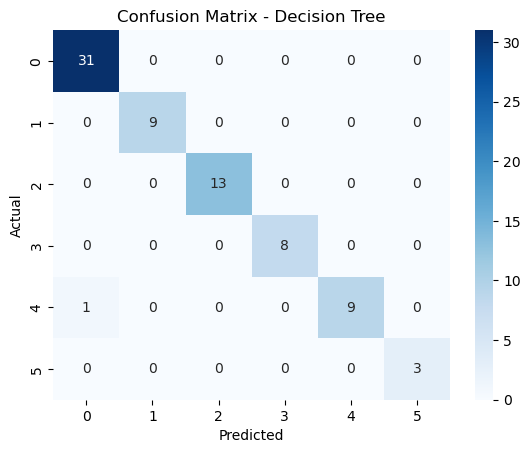

In [24]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
print("Decision Tree Report")

print(classification_report(y_test, y_pred_dt))

Decision Tree Report
              precision    recall  f1-score   support

           1       0.97      1.00      0.98        31
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      0.90      0.95        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.99      0.98      0.99        74
weighted avg       0.99      0.99      0.99        74



### Decision Tree Evaluation Analysis

The confusion matrix indicates that the Decision Tree model correctly predicts most disease classes, with very few misclassifications.

The classification report shows high precision, recall, and F1-scores across classes, demonstrating the model’s ability to capture complex relationships between features.

Decision Trees are capable of learning non-linear patterns in the data. However, they can sometimes overfit small datasets, which is why ensemble methods such as Random Forest are often considered more robust.

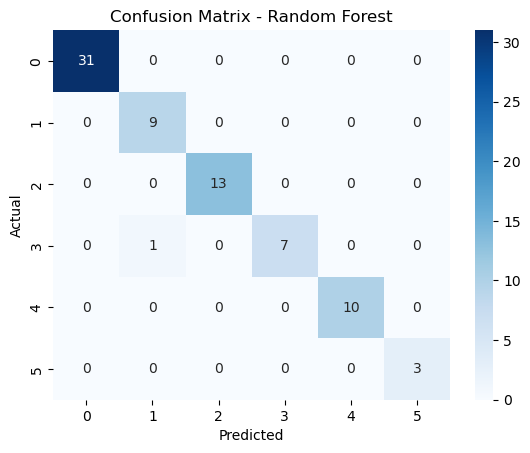

In [26]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
print("Random Forest Report")

print(classification_report(y_test, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



### Random Forest Evaluation Analysis

The confusion matrix demonstrates that Random Forest achieves highly accurate predictions, with most observations correctly classified.

The classification report shows excellent precision, recall, and F1-scores across all classes, indicating strong predictive performance.

Random Forest combines multiple decision trees to produce more stable and reliable predictions. This ensemble approach helps reduce overfitting and improves generalization, making Random Forest the most suitable model for this classification task.

## Feature Importance

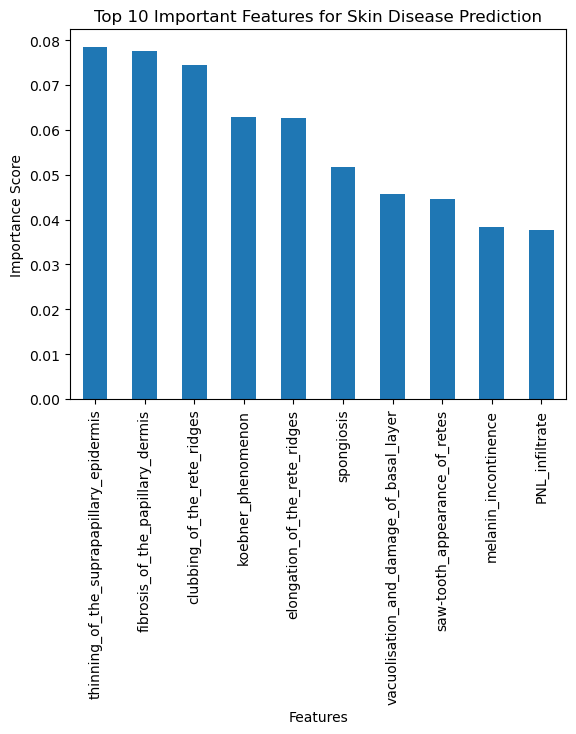

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important Features for Skin Disease Prediction")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

### Feature Importance Analysis

Random Forest provides a feature importance score which indicates how influential each feature is in predicting the target variable. 

From the visualization above, we can identify the most significant clinical and histopathological attributes contributing to the classification of skin diseases. These features play a crucial role in helping the model distinguish between different disease categories.

## Challenges Faced

During the development of this project, several challenges were encountered:

• The dataset contained missing values in the Age column represented as "?", which required cleaning and conversion to numerical format.

• The dataset contains a large number of medical attributes which required careful preprocessing and feature handling.

• Logistic Regression required proper feature scaling to ensure stable model convergence.

• Since the dataset size is relatively small, there is a possibility of models achieving very similar accuracy scores.

## Conclusion

In this project, multiple machine learning models were implemented to classify skin diseases based on clinical and histopathological features.

Three models were trained and evaluated:

• Logistic Regression  
• Decision Tree  
• Random Forest  

All models achieved very high accuracy due to the well-structured nature of the dataset and the strong predictive power of the features.

Among the models, Random Forest was selected as the most reliable model because it combines multiple decision trees and generally provides better generalization performance.

Overall, the results demonstrate that machine learning techniques can effectively assist in the classification of dermatological conditions using structured medical data.

## Future Improvements

Several improvements can be explored in future work:

• Applying advanced ensemble algorithms such as XGBoost or Gradient Boosting.

• Performing systematic hyperparameter tuning using GridSearchCV or RandomizedSearchCV.

• Increasing dataset size to improve model generalization.

• Using cross-validation to obtain more reliable evaluation metrics.